In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving superstore_final_dataset (1).csv to superstore_final_dataset (1).csv


In [ ]:
df = pd.read_csv('/content/superstore_final_dataset (1).csv', encoding='latin1')


In [ ]:
print(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip()

df['Order Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')


In [ ]:
df = df.dropna()

In [ ]:
# 📌 FEATURE ENGINEERING
# ==============================
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()


/tmp/ipykernel_12908/885757744.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Order Date'].dt.year
/tmp/ipykernel_12908/885757744.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Order Date'].dt.month
/tmp/ipykernel_12908/885757744.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [ ]:
# Revenue
total_revenue = df['Sales'].sum()

# Check if Profit exists
if 'Profit' in df.columns:
    total_profit = df['Profit'].sum()
    profit_margin = total_profit / total_revenue
else:
    total_profit = "Not Available"
    profit_margin = "Not Available"

# AOV
aov = df.groupby('Order_ID')['Sales'].sum().mean()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Profit Margin:", profit_margin)
print("Average Order Value:", aov)

Total Revenue: 865743.2436
Total Profit: Not Available
Profit Margin: Not Available
Average Order Value: 439.24061065449007


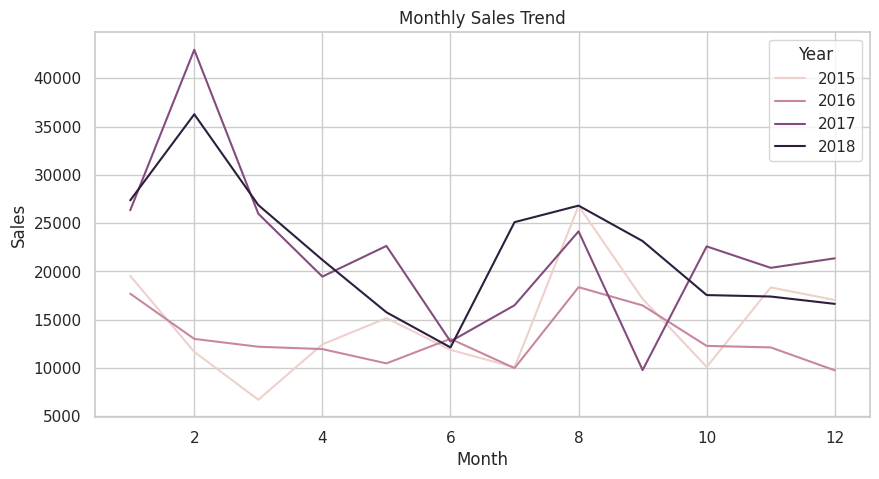

In [ ]:
#SALES TREND (TIME)
# ==============================
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year')
plt.title("Monthly Sales Trend")
plt.show()


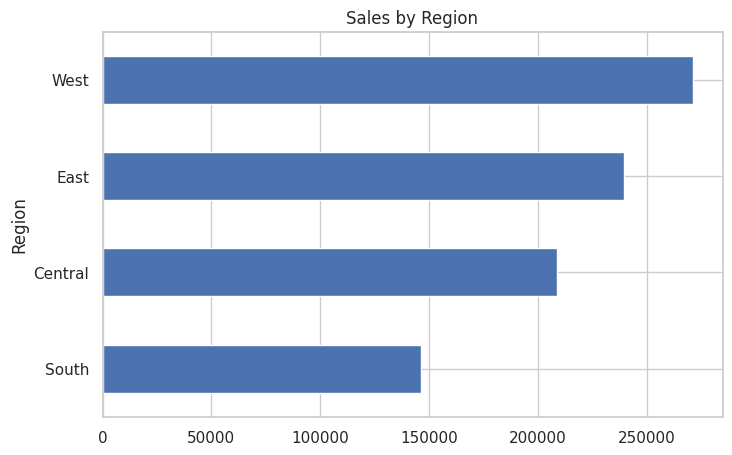

In [ ]:
# 🌍 REGION ANALYSIS
# ==============================
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='barh', figsize=(8,5))
plt.title("Sales by Region")
plt.show()

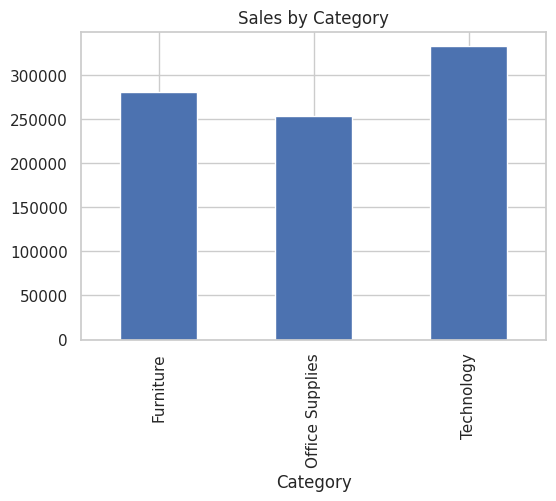

In [ ]:
# 🛍 CATEGORY ANALYSIS
# ==============================
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', figsize=(6,4))
plt.title("Sales by Category")
plt.show()

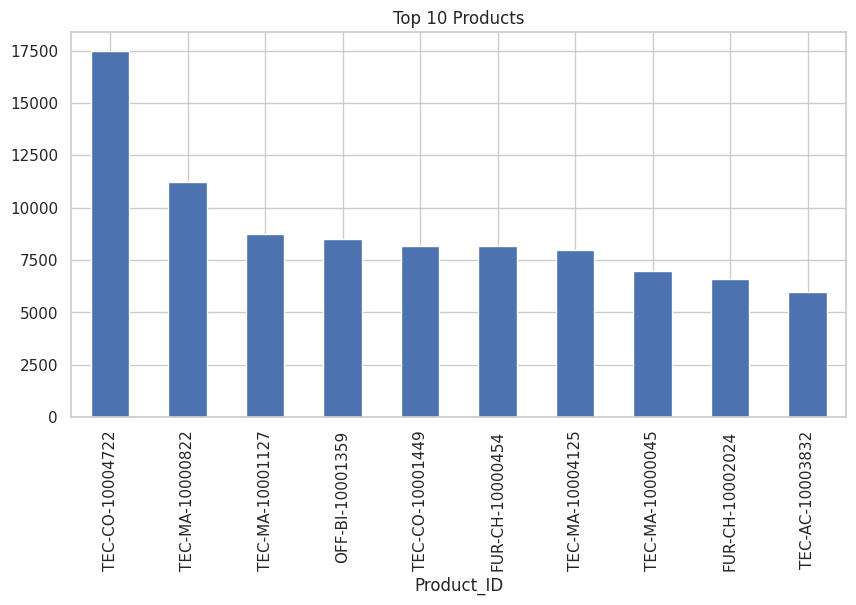

In [ ]:
# 🏆 TOP PRODUCTS
# ==============================
top_products = df.groupby('Product_ID')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products")
plt.show()

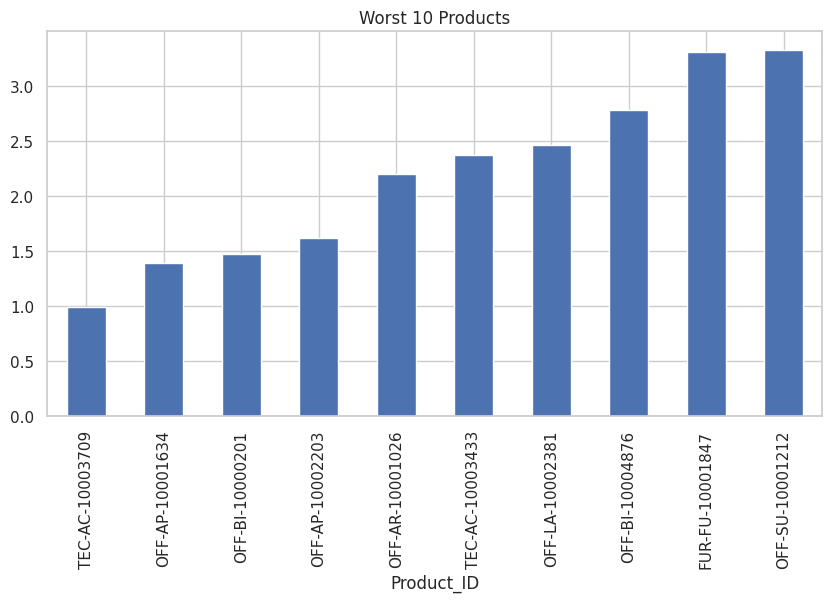

In [ ]:
# ❌ WORST PRODUCTS
# ==============================
worst_products = df.groupby('Product_ID')['Sales'].sum().sort_values().head(10)

worst_products.plot(kind='bar', figsize=(10,5))
plt.title("Worst 10 Products")
plt.show()




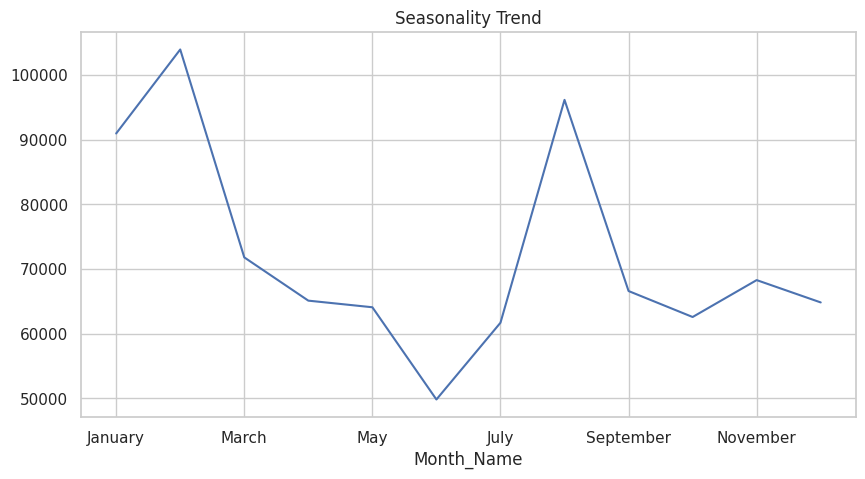

In [ ]:
# 📅 SEASONALITY ANALYSIS
# ==============================
seasonality = df.groupby('Month_Name')['Sales'].sum()

seasonality = seasonality.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

seasonality.plot(figsize=(10,5))
plt.title("Seasonality Trend")
plt.show()